In [6]:
# %pip install pandas matplotlib

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("ROUND1/trades_round_1_day_-2.csv", delimiter=";")
df.columns = df.columns.str.strip()
df["buyer"] = df["buyer"].fillna("")
df["seller"] = df["seller"].fillna("")
df["price"] = pd.to_numeric(df["price"], errors="coerce")
df = df.sort_values(["symbol", "timestamp"]).reset_index(drop=True)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Dtypes:\n", df.dtypes)
print()
print(df.head(10).to_string(index=False))
df

Shape: (773, 7)
Columns: ['timestamp', 'buyer', 'seller', 'symbol', 'currency', 'price', 'quantity']
Dtypes:
 timestamp      int64
buyer         object
seller        object
symbol        object
currency      object
price        float64
quantity       int64
dtype: object

 timestamp buyer seller            symbol currency   price  quantity
       700              ASH_COATED_OSMIUM   XIRECS  9990.0         6
       900              ASH_COATED_OSMIUM   XIRECS  9998.0         2
      2500              ASH_COATED_OSMIUM   XIRECS 10011.0         8
      6100              ASH_COATED_OSMIUM   XIRECS 10013.0         8
     12900              ASH_COATED_OSMIUM   XIRECS 10001.0         9
     13800              ASH_COATED_OSMIUM   XIRECS 10017.0         3
     15000              ASH_COATED_OSMIUM   XIRECS 10016.0         3
     15100              ASH_COATED_OSMIUM   XIRECS 10016.0         5
     15900              ASH_COATED_OSMIUM   XIRECS  9995.0         9
     17400              ASH_COATED_OSM

,timestamp,buyer,seller,symbol,currency,price,quantity
0,700,,,ASH_COATED_OSMIUM,XIRECS,9990.0,6
1,900,,,ASH_COATED_OSMIUM,XIRECS,9998.0,2
2,2500,,,ASH_COATED_OSMIUM,XIRECS,10011.0,8
3,6100,,,ASH_COATED_OSMIUM,XIRECS,10013.0,8
4,12900,,,ASH_COATED_OSMIUM,XIRECS,10001.0,9
...,...,...,...,...,...,...,...
768,981900,,,INTARIAN_PEPPER_ROOT,XIRECS,10985.0,3
769,982600,,,INTARIAN_PEPPER_ROOT,XIRECS,10974.0,7
770,985200,,,INTARIAN_PEPPER_ROOT,XIRECS,10994.0,4
771,989100,,,INTARIAN_PEPPER_ROOT,XIRECS,10980.0,6


In [7]:
summary = df.groupby("symbol").agg(
    trades=("price", "size"),
    total_quantity=("quantity", "sum"),
    mean_price=("price", "mean"),
    median_price=("price", "median"),
    min_price=("price", "min"),
    max_price=("price", "max"),
).sort_values("trades", ascending=False)

print("Unique symbols:", df["symbol"].nunique())
print("Timestamp range:", int(df["timestamp"].min()), "to", int(df["timestamp"].max()))
print()
print(summary.to_string())

for symbol, subset in df.groupby("symbol"):
    print()
    print("=" * 10, symbol, "=" * 10)
    print(subset[["timestamp", "price", "quantity"]].head(8).to_string(index=False))

Unique symbols: 2
Timestamp range: 700 to 997500

                      trades  total_quantity    mean_price  median_price  min_price  max_price
symbol                                                                                        
ASH_COATED_OSMIUM        429            2210   9998.200466        9999.0     9979.0    10018.0
INTARIAN_PEPPER_ROOT     344            1745  10495.700581       10508.5     9995.0    10994.0

========== ASH_COATED_OSMIUM ==========
 timestamp   price  quantity
       700  9990.0         6
       900  9998.0         2
      2500 10011.0         8
      6100 10013.0         8
     12900 10001.0         9
     13800 10017.0         3
     15000 10016.0         3
     15100 10016.0         5

========== INTARIAN_PEPPER_ROOT ==========
 timestamp   price  quantity
      1000  9995.0         7
      4000 10007.0         7
     10500 10013.0         5
     12600 10018.0         3
     15000 10021.0         7
     15600 10021.0         3
     20200 10026.0   

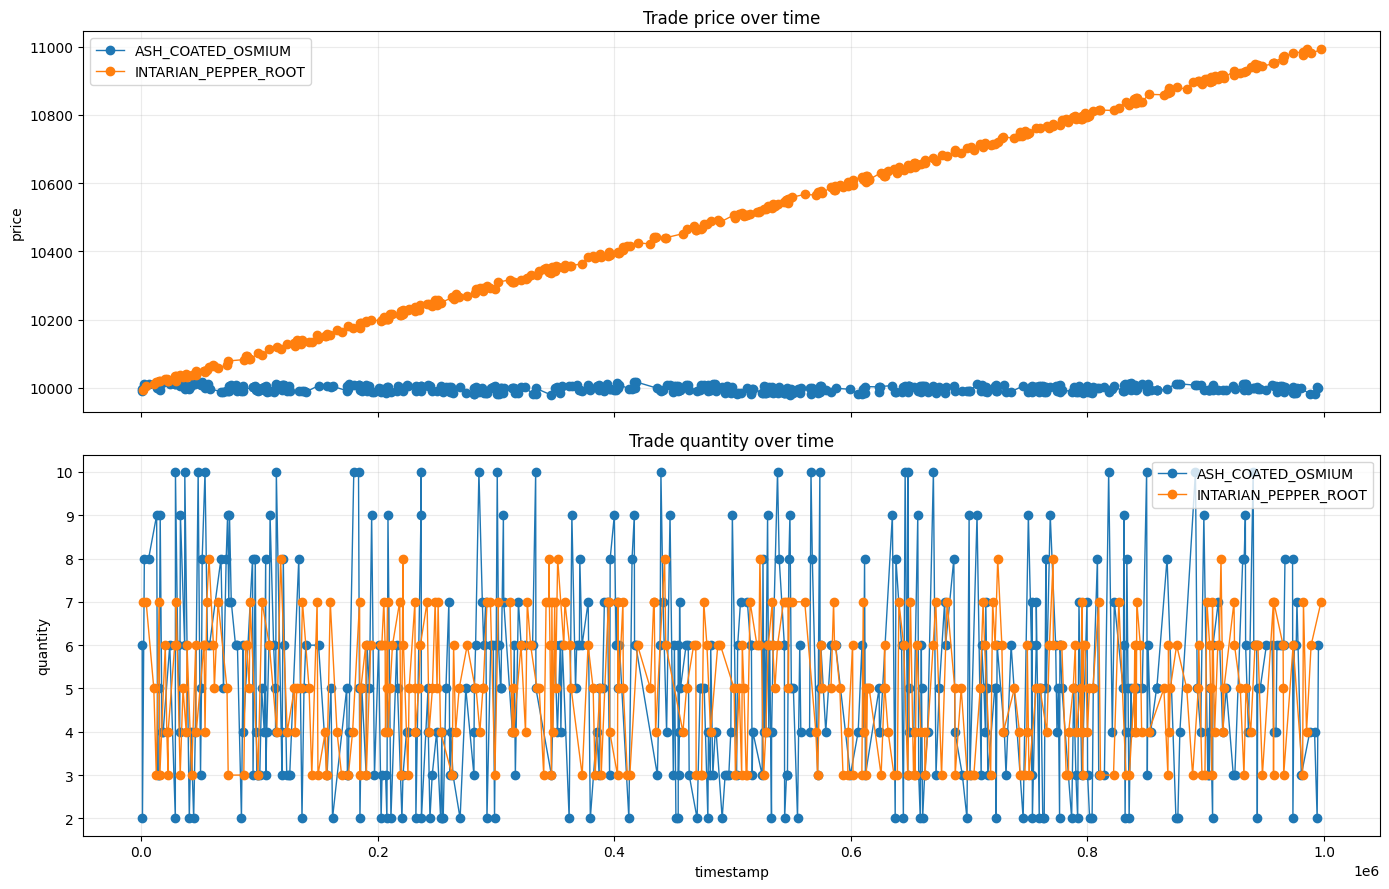

Price spread by symbol:
symbol
INTARIAN_PEPPER_ROOT    999.0
ASH_COATED_OSMIUM        39.0


In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

for symbol, subset in df.groupby("symbol"):
    axes[0].plot(subset["timestamp"], subset["price"], marker="o", linewidth=1, label=symbol)
    axes[1].plot(subset["timestamp"], subset["quantity"], marker="o", linewidth=1, label=symbol)

axes[0].set_title("Trade price over time")
axes[0].set_ylabel("price")
axes[0].legend()
axes[0].grid(True, alpha=0.25)

axes[1].set_title("Trade quantity over time")
axes[1].set_ylabel("quantity")
axes[1].set_xlabel("timestamp")
axes[1].legend()
axes[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

price_spread = df.groupby("symbol")["price"].agg(lambda s: s.max() - s.min()).sort_values(ascending=False)
print("Price spread by symbol:")
print(price_spread.to_string())